# PART2_phenotype_stats
Check distribution of phenotype values for each RIL

Check correlations between traits

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm import tqdm
import copy

sns.set()
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

# check phenotype distribution
# Traits: LW, LL, DTH, PN, GN, GS

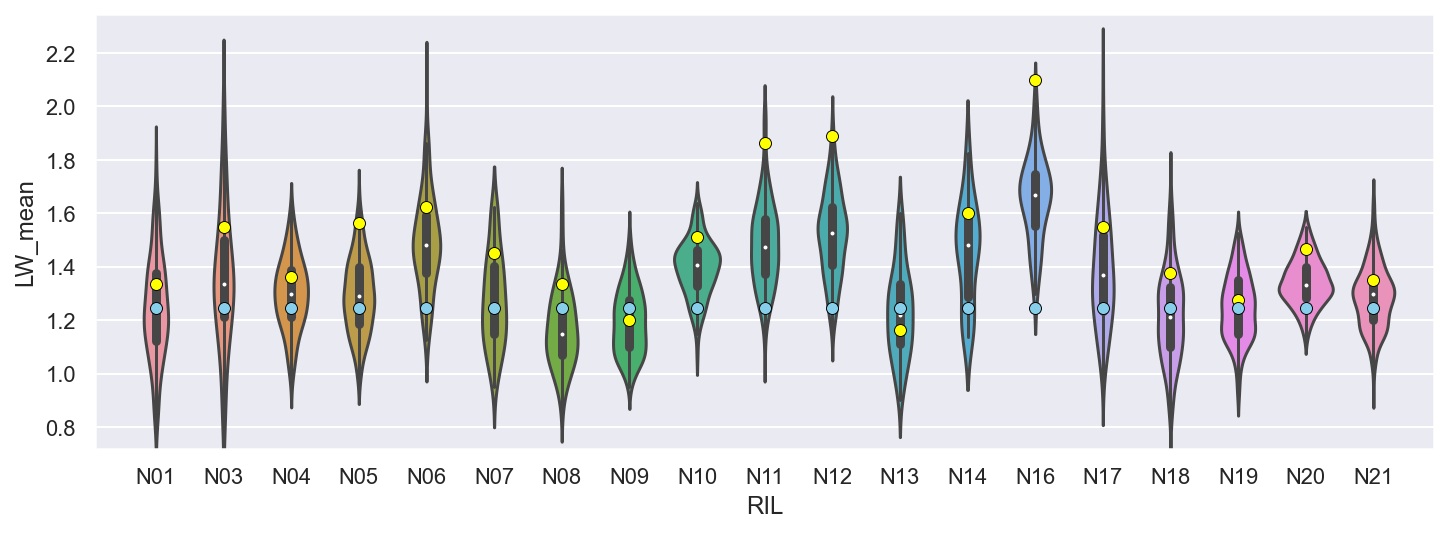

<Figure size 432x288 with 0 Axes>

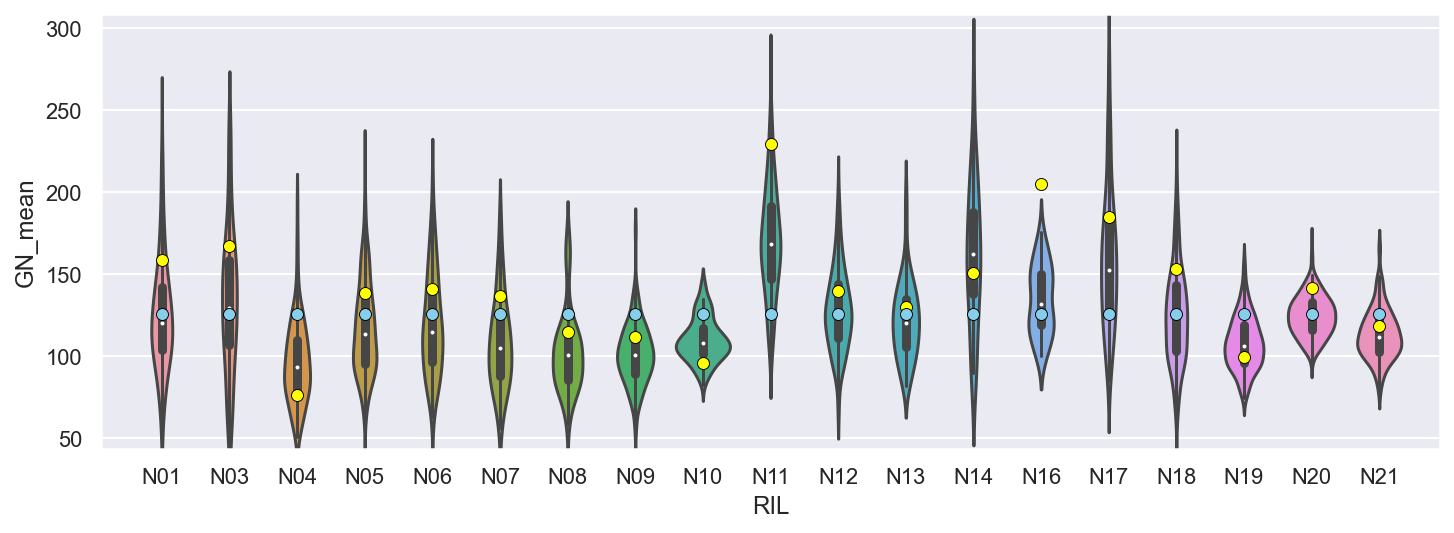

<Figure size 432x288 with 0 Axes>

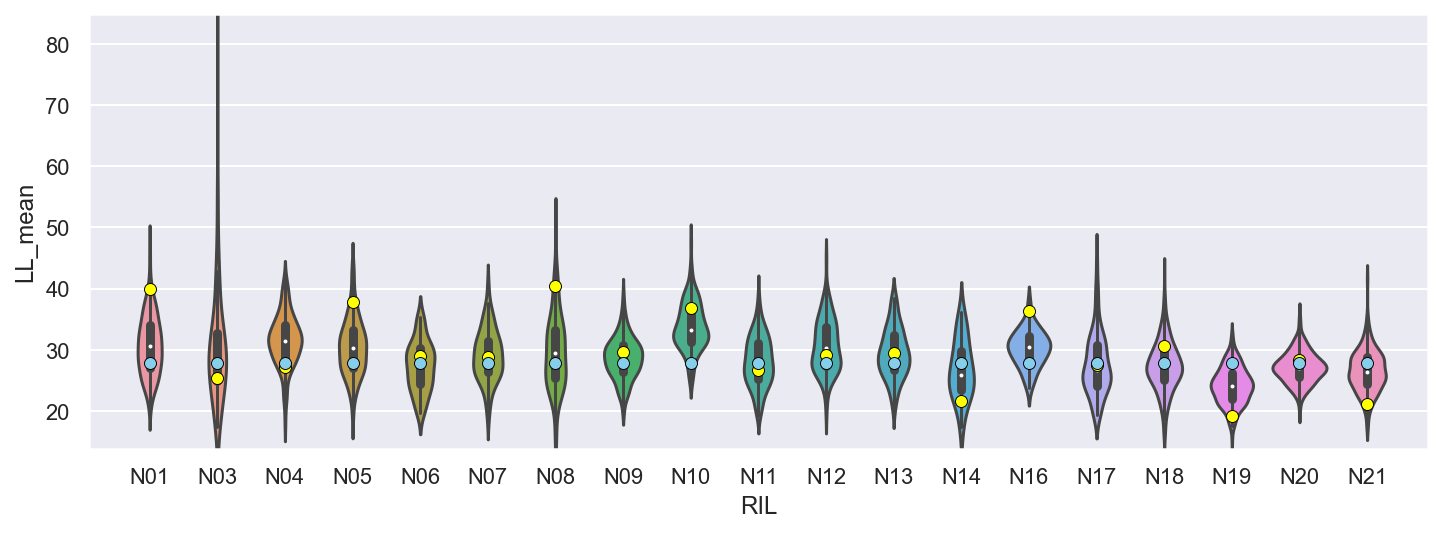

<Figure size 432x288 with 0 Axes>

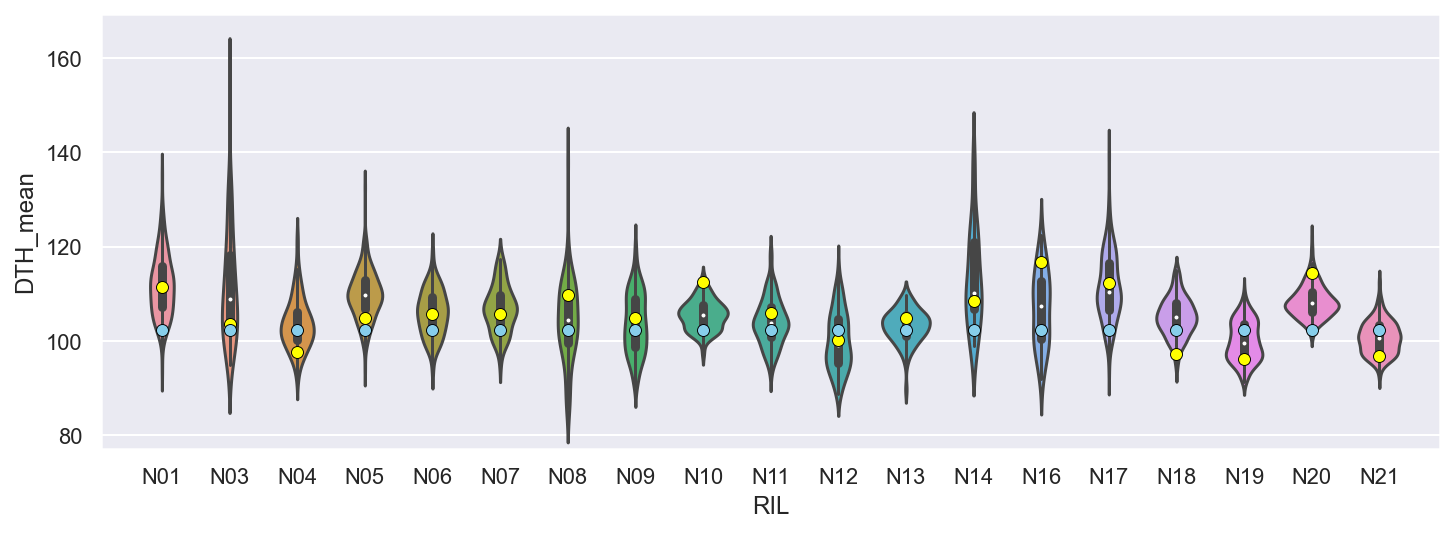

<Figure size 432x288 with 0 Axes>

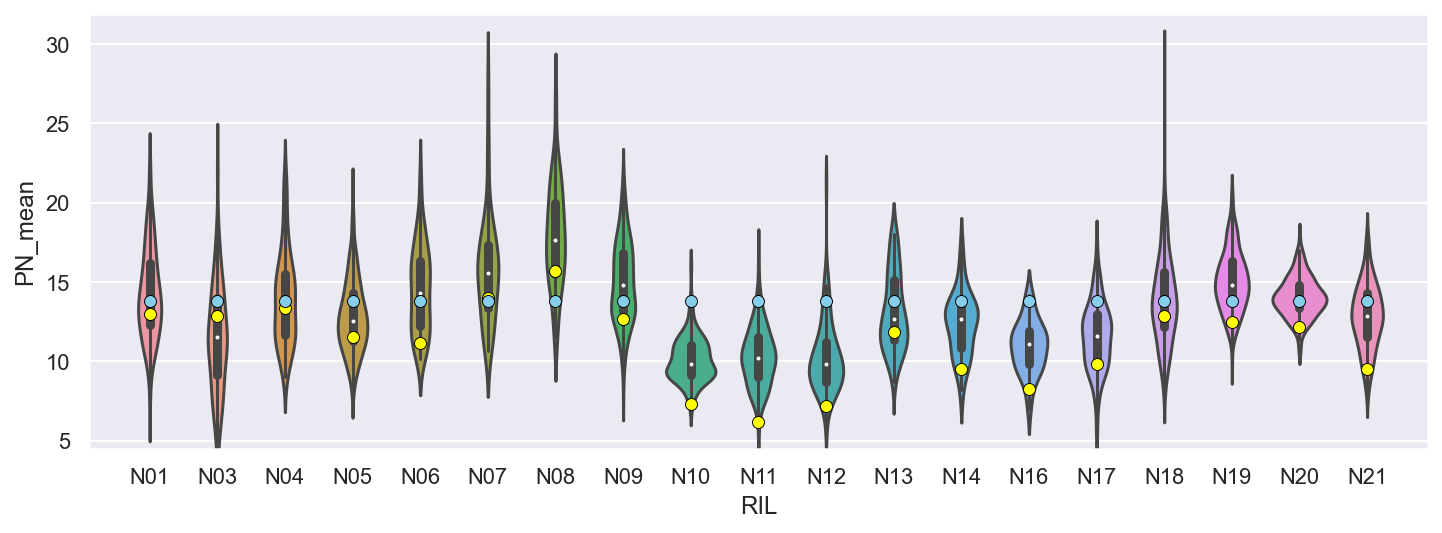

<Figure size 432x288 with 0 Axes>

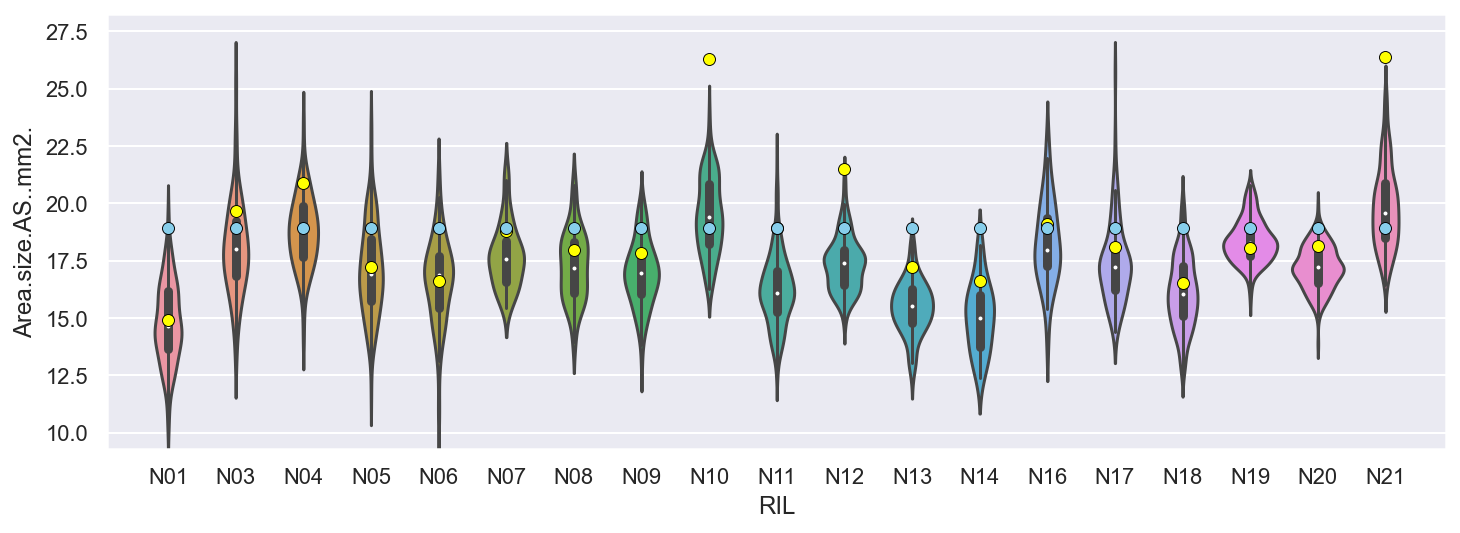

<Figure size 432x288 with 0 Axes>

In [33]:
# get phenotype data
phenotype_data = pd.read_csv("../data/phenotype_data/mean_phenotypes.csv", index_col=0)
parents_data = pd.read_csv("../data/phenotype_data/mean_phenotypes_parents.csv", index_col=0)
# edit ids of donor parents & common parent
founder_data = parents_data.loc[(parents_data.index.str.contains("999")) & (~parents_data.index.str.contains("N22")), :].copy()
founder_data["RIL"] = founder_data.index.str[:3]
Hitome_data = parents_data.loc[(parents_data.index.str.contains("000")) & (~parents_data.index.str.contains("N22")), :].copy()
Hitome_data["RIL"] = Hitome_data.index.str[:3]

# visualize violinplot of phenotypic variation for each trait & each RIL population
for i in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    tmp_data = phenotype_data.loc[:, ["Line", i]]
    tmp_data["RIL"] = tmp_data.Line.str[:3]
    Hitome_data[i] = Hitome_data[i].mean()

    fig = plt.figure(figsize=(12,4))
    ax = fig.add_subplot(1, 1, 1)
    sns.violinplot(x='RIL', y=i, data=tmp_data, jitter=True, ax=ax)
    sns.scatterplot(x='RIL', y=i, data=founder_data, ax=ax, zorder=10, color="yellow", edgecolor="black")
    sns.scatterplot(x='RIL', y=i, data=Hitome_data, ax=ax, zorder=10, color="skyblue", edgecolor="black")
    
    ax.set_ylim(tmp_data[i].min()*0.9, tmp_data[i].max()*1.1)
    ax.set_xlabel('RIL')
    ax.set_ylabel(i)
    plt.show()
    plt.clf()

# Trade-off relationships

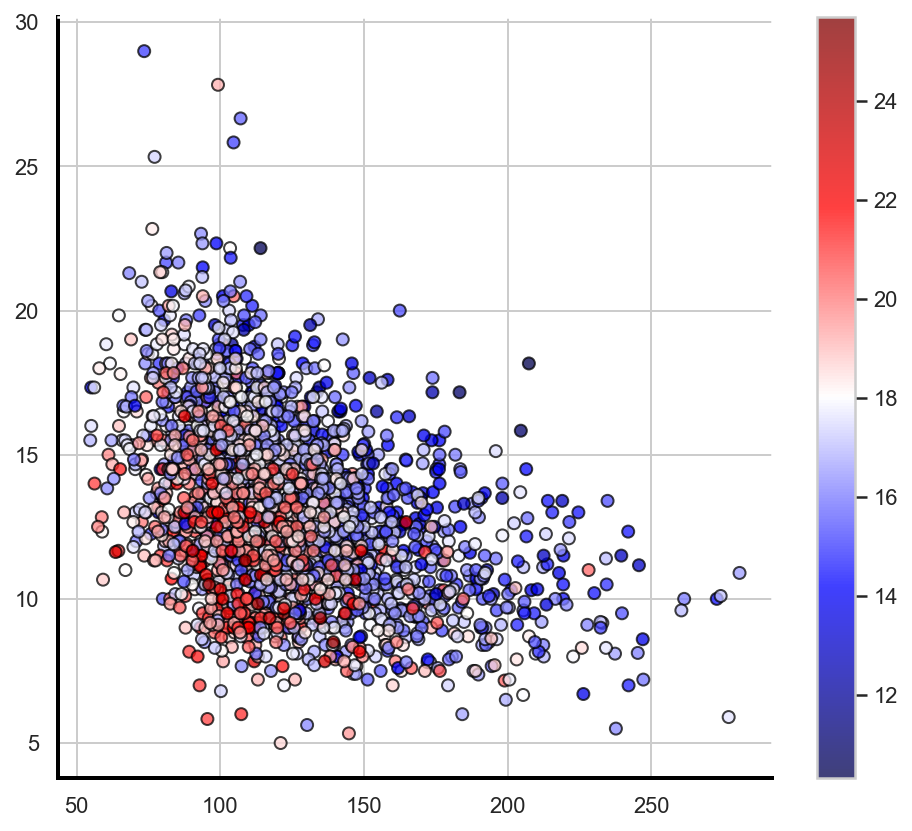

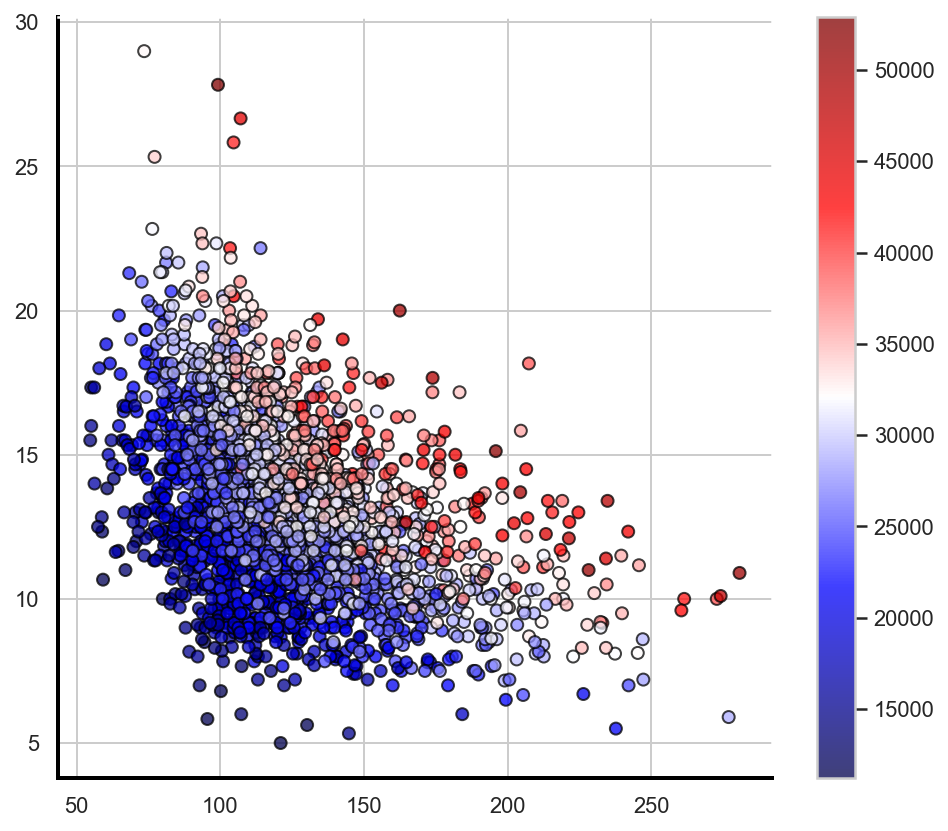

In [21]:
# visualize trade-off of GN, PN, GS
sns.set(style='whitegrid', color_codes=True)

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(1,1,1)
sc = ax.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], c=phenotype_data["Area.size.AS..mm2."], alpha=0.75, edgecolor="black", cmap=cm.seismic)
plt.colorbar(sc)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color('black')
    ax.spines[sp].set_linewidth(2)
for sp in ["right", "top"]:
    ax.spines[sp].set_color('white')
plt.show()

# visualize trade-off of GN, PN, GN*PN*GS
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(1,1,1)
sc = ax.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], c=phenotype_data["GN_mean"]*phenotype_data["PN_mean"]*phenotype_data["Area.size.AS..mm2."], alpha=0.75, edgecolor="black", cmap=cm.seismic)
plt.colorbar(sc)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color('black')
    ax.spines[sp].set_linewidth(2)
for sp in ["right", "top"]:
    ax.spines[sp].set_color('white')
plt.show()